In [20]:
import xarray as xr
import numpy as np
import glob as glob
import functions
import matplotlib.pyplot as plt
import seaborn as sns
import cmcrameri

In [2]:
rpath = '/nird/datapeak/NS9600K/astridbg/arctic-cld-feedbacks/data/land_vars/'
ds_piClim = xr.open_dataset(rpath+'all_land_vars_piClim.nc')
ds_2xCO2 = xr.open_dataset(rpath+'all_land_vars_2xCO2.nc')
ds_4xCO2 = xr.open_dataset(rpath+'all_land_vars_4xCO2.nc')

In [29]:
rpath = '/nird/datapeak/NS9600K/astridbg/arctic-cld-feedbacks/data/'
ds_piClim_xtra = xr.open_dataset(rpath+'N1850_f19_tn14_noresm2_3_slf_output_20250529.soilsat.clm2.concatfiles.nc')
ds_2xCO2_xtra = xr.open_dataset(rpath+'N1850_f19_tn14_noresm2_3_slf_output_2xCO2_20250529.soilsat.clm2.concatfiles.nc')
ds_4xCO2_xtra = xr.open_dataset(rpath+'N1850_f19_tn14_noresm2_3_slf_output_4xCO2_20250529.soilsat.clm2.concatfiles.nc')

ds_piClim_xtra = functions.fix_clm_time(ds_piClim_xtra)
ds_2xCO2_xtra = functions.fix_clm_time(ds_2xCO2_xtra)
ds_4xCO2_xtra = functions.fix_clm_time(ds_4xCO2_xtra)

# Create new variables
ds_list = [ds_piClim, ds_2xCO2, ds_4xCO2]
ds_xtra_list = [ds_piClim_xtra, ds_2xCO2_xtra, ds_4xCO2_xtra]
for ds, ds_xtra in zip(ds_list, ds_xtra_list):
    tmp = ds_xtra['H2OSOI']
    tmp_i = tmp.sel(levsoi=0) + tmp.sel(levsoi=1) + 2/3*tmp.sel(levsoi=2)
    ds['H2OSOI_10CM'] = tmp_i

    tmp_i = tmp.sel(levsoi=0) + tmp.sel(levsoi=1) + tmp.sel(levsoi=2) + tmp.sel(levsoi=3)
    ds['H2OSOI_20CM'] = tmp_i

    tmp2 = ds_xtra['WATSAT']
    tmp2_i = tmp2.isel(levgrnd=0) + tmp2.isel(levgrnd=1) + 2/3*tmp2.isel(levgrnd=2)
    ds['WATSAT_10CM'] = tmp2_i

    tmp2_i = tmp2.isel(levgrnd=0) + tmp2.isel(levgrnd=1) + tmp2.isel(levgrnd=2) + tmp2.isel(levgrnd=3)
    ds['WATSAT_20CM'] = tmp2_i

    ds['FSOILSAT_10CM'] = ds['H2OSOI_10CM']/ds['WATSAT_10CM']
    ds['FSOILSAT_20CM'] = ds['H2OSOI_20CM']/ds['WATSAT_20CM']
    

In [30]:
rpath = '/nird/datapeak/NS9600K/astridbg/arctic-cld-feedbacks/data/'
ds_piClim_xtra = xr.open_dataset(rpath+'N1850_f19_tn14_noresm2_3_slf_output_20250529.soilliq.clm2.concatfiles.nc')
ds_2xCO2_xtra = xr.open_dataset(rpath+'N1850_f19_tn14_noresm2_3_slf_output_2xCO2_20250529.soilliq.clm2.concatfiles.nc')
ds_4xCO2_xtra = xr.open_dataset(rpath+'N1850_f19_tn14_noresm2_3_slf_output_4xCO2_20250529.soilliq.clm2.concatfiles.nc')

In [31]:
# Fix time stamp
ds_piClim_xtra = functions.fix_clm_time(ds_piClim_xtra)
ds_2xCO2_xtra = functions.fix_clm_time(ds_2xCO2_xtra)
ds_4xCO2_xtra = functions.fix_clm_time(ds_4xCO2_xtra)

In [32]:
# Create new variables
ds_list = [ds_piClim, ds_2xCO2, ds_4xCO2]
ds_xtra_list = [ds_piClim_xtra, ds_2xCO2_xtra, ds_4xCO2_xtra]
for ds, ds_xtra in zip(ds_list, ds_xtra_list):
    tmp = ds_xtra['SOILICE'] + ds_xtra['SOILLIQ']
    tmp_i = tmp.sel(levsoi=0) + tmp.sel(levsoi=1) + 2/3*tmp.sel(levsoi=2)
    ds['SOILWATER_10CM_corrected'] = tmp_i

    tmp_i = tmp.sel(levsoi=0) + tmp.sel(levsoi=1) + tmp.sel(levsoi=2) + tmp.sel(levsoi=3)
    ds['SOILWATER_20CM'] = tmp_i

MemoryError: Unable to allocate 3.71 GiB for an array with shape (1800, 20, 96, 144) and data type float64

In [ ]:
ds_piClim

In [7]:
rpath = '/nird/datapeak/NS9600K/astridbg/arctic-cld-feedbacks/data/'
ds_piClim_xtra = xr.open_dataset(rpath+'N1850_f19_tn14_noresm2_3_slf_output_20250529.snow.clm2.concatfiles.nc')
ds_2xCO2_xtra = xr.open_dataset(rpath+'N1850_f19_tn14_noresm2_3_slf_output_2xCO2_20250529.snow.clm2.concatfiles.nc')
ds_4xCO2_xtra = xr.open_dataset(rpath+'N1850_f19_tn14_noresm2_3_slf_output_4xCO2_20250529.snow.clm2.concatfiles.nc')

In [8]:
# Fix time stamp
ds_piClim_xtra = functions.fix_clm_time(ds_piClim_xtra)
ds_2xCO2_xtra = functions.fix_clm_time(ds_2xCO2_xtra)
ds_4xCO2_xtra = functions.fix_clm_time(ds_4xCO2_xtra)

In [9]:
# Create new variables
ds_list = [ds_piClim, ds_2xCO2, ds_4xCO2]
ds_xtra_list = [ds_piClim_xtra, ds_2xCO2_xtra, ds_4xCO2_xtra]
for ds, ds_xtra in zip(ds_list, ds_xtra_list):
    ds['SNOW_FROM_ATM'] = ds_xtra['SNOW_FROM_ATM']

In [10]:
# Create new variables
ds_list = [ds_piClim, ds_2xCO2, ds_4xCO2]
for ds in ds_list:
    ds['PRECIP_TOTAL'] = ds['SNOW_FROM_ATM']+ds['RAIN_FROM_ATM']

In [11]:
rpath = '/nird/datapeak/NS9600K/astridbg/arctic-cld-feedbacks/data/'
ds_piClim_xtra = xr.open_dataset(rpath+'N1850_f19_tn14_noresm2_3_slf_output_20250529.extra2.clm2.concatfiles.nc')
ds_2xCO2_xtra = xr.open_dataset(rpath+'N1850_f19_tn14_noresm2_3_slf_output_2xCO2_20250529.extra2.clm2.concatfiles.nc')
ds_4xCO2_xtra = xr.open_dataset(rpath+'N1850_f19_tn14_noresm2_3_slf_output_4xCO2_20250529.extra2.clm2.concatfiles.nc')

In [12]:
# Fix time stamp
ds_piClim_xtra = functions.fix_clm_time(ds_piClim_xtra)
ds_2xCO2_xtra = functions.fix_clm_time(ds_2xCO2_xtra)
ds_4xCO2_xtra = functions.fix_clm_time(ds_4xCO2_xtra)

In [13]:
# Create new variables
ds_list = [ds_piClim, ds_2xCO2, ds_4xCO2]
ds_xtra_list = [ds_piClim_xtra, ds_2xCO2_xtra, ds_4xCO2_xtra]
for ds, ds_xtra in zip(ds_list, ds_xtra_list):
    ds['SNOW'] = ds_xtra['SNOW']
    ds['RAIN'] = ds_xtra['RAIN']
    ds['FSNO'] = ds_xtra['FSNO']
    ds['FSNO_EFF'] = ds_xtra['FSNO_EFF']
    ds['FSH_TO_COUPLER'] = ds_xtra['FSH_TO_COUPLER']
    ds['EFLX_LH_TOT'] = ds_xtra['EFLX_LH_TOT']

In [15]:
rpath = '/nird/datapeak/NS9600K/astridbg/arctic-cld-feedbacks/data/'
ds_piClim_xtra = xr.open_dataset(rpath+'N1850_f19_tn14_noresm2_3_slf_output_20250529.evaptemp.clm2.concatfiles.nc')
ds_2xCO2_xtra = xr.open_dataset(rpath+'N1850_f19_tn14_noresm2_3_slf_output_2xCO2_20250529.evaptemp.clm2.concatfiles.nc')
ds_4xCO2_xtra = xr.open_dataset(rpath+'N1850_f19_tn14_noresm2_3_slf_output_4xCO2_20250529.evaptemp.clm2.concatfiles.nc')

In [16]:
# Fix time stamp
ds_piClim_xtra = functions.fix_clm_time(ds_piClim_xtra)
ds_2xCO2_xtra = functions.fix_clm_time(ds_2xCO2_xtra)
ds_4xCO2_xtra = functions.fix_clm_time(ds_4xCO2_xtra)

In [17]:
# Create new variables
ds_list = [ds_piClim, ds_2xCO2, ds_4xCO2]
ds_xtra_list = [ds_piClim_xtra, ds_2xCO2_xtra, ds_4xCO2_xtra]
for ds, ds_xtra in zip(ds_list, ds_xtra_list):
    ds['TSA'] = ds_xtra['TSA']

In [18]:
# Make a spatial average
Arctic_lim = 60
tslice = slice('2040-01-01','2069-12-31')
lons = slice(0,300)

# Choose area
area_weights = ds_piClim['area'].sel(lat=slice(Arctic_lim,90),lon=lons)/(ds_piClim['area'].sel(lat=slice(Arctic_lim,90),lon=lons).sum())
ds_piClim_i = ds_piClim.sel(lat=slice(Arctic_lim,90), lon=lons, time=tslice)
ds_2xCO2_i = ds_2xCO2.sel(lat=slice(Arctic_lim,90), lon=lons, time=tslice)
ds_4xCO2_i = ds_4xCO2.sel(lat=slice(Arctic_lim,90), lon=lons, time=tslice)

# Monthly averages
ds_piClim_i = ds_piClim_i.groupby(ds_piClim_i.time.dt.month).mean('time')
ds_2xCO2_i = ds_2xCO2_i.groupby(ds_2xCO2_i.time.dt.month).mean('time')
ds_4xCO2_i = ds_4xCO2_i.groupby(ds_4xCO2_i.time.dt.month).mean('time')


### RELATIVE HUMIDITY ###

rpath= '/nird/datapeak/NS9600K/astridbg/arctic-cld-feedbacks/data/other_cloud_vars/'

landmask = xr.open_dataarray(rpath+'LANDFRAC_piClim.nc')
landmask = landmask.isel(time=0)
oceanmask = 1-landmask

ds_piClim_RH = xr.open_mfdataset([rpath+'RELHUM_piClim.nc', rpath+'CLDLOW_piClim.nc'])
ds_2xCO2_RH = xr.open_mfdataset([rpath+'RELHUM_abrupt-2xCO2.nc', rpath+'CLDLOW_abrupt-2xCO2.nc'])
ds_4xCO2_RH = xr.open_mfdataset([rpath+'RELHUM_abrupt-4xCO2.nc', rpath+'CLDLOW_abrupt-4xCO2.nc'])
lev = ds_piClim_RH.lev[-1]
tslice = slice('2040-01-01', '2069-12-31')

ds_piClim_RH = ds_piClim_RH.sel(lev=lev, time=tslice)
ds_2xCO2_RH = ds_2xCO2_RH.sel(lev=lev, time=tslice)
ds_4xCO2_RH = ds_4xCO2_RH.sel(lev=lev, time=tslice)

piClim_m = ds_piClim_RH.groupby(ds_piClim_RH.time.dt.month).mean('time')
ds_2xCO2_m = ds_2xCO2_RH.groupby(ds_2xCO2_RH.time.dt.month).mean('time')
ds_4xCO2_m = ds_4xCO2_RH.groupby(ds_4xCO2_RH.time.dt.month).mean('time')

piClim_RH_lnd = functions.computeWeightedMeanMasked(piClim_m.sel(lat=slice(Arctic_lim, 90), lon=lons), landmask.sel(lat=slice(Arctic_lim,90), lon=lons))
ds_2xCO2_RH_lnd = functions.computeWeightedMeanMasked(ds_2xCO2_m.sel(lat=slice(Arctic_lim, 90),lon=lons), landmask.sel(lat=slice(Arctic_lim,90), lon=lons))
ds_4xCO2_RH_lnd = functions.computeWeightedMeanMasked(ds_4xCO2_m.sel(lat=slice(Arctic_lim, 90), lon=lons), landmask.sel(lat=slice(Arctic_lim,90), lon=lons))

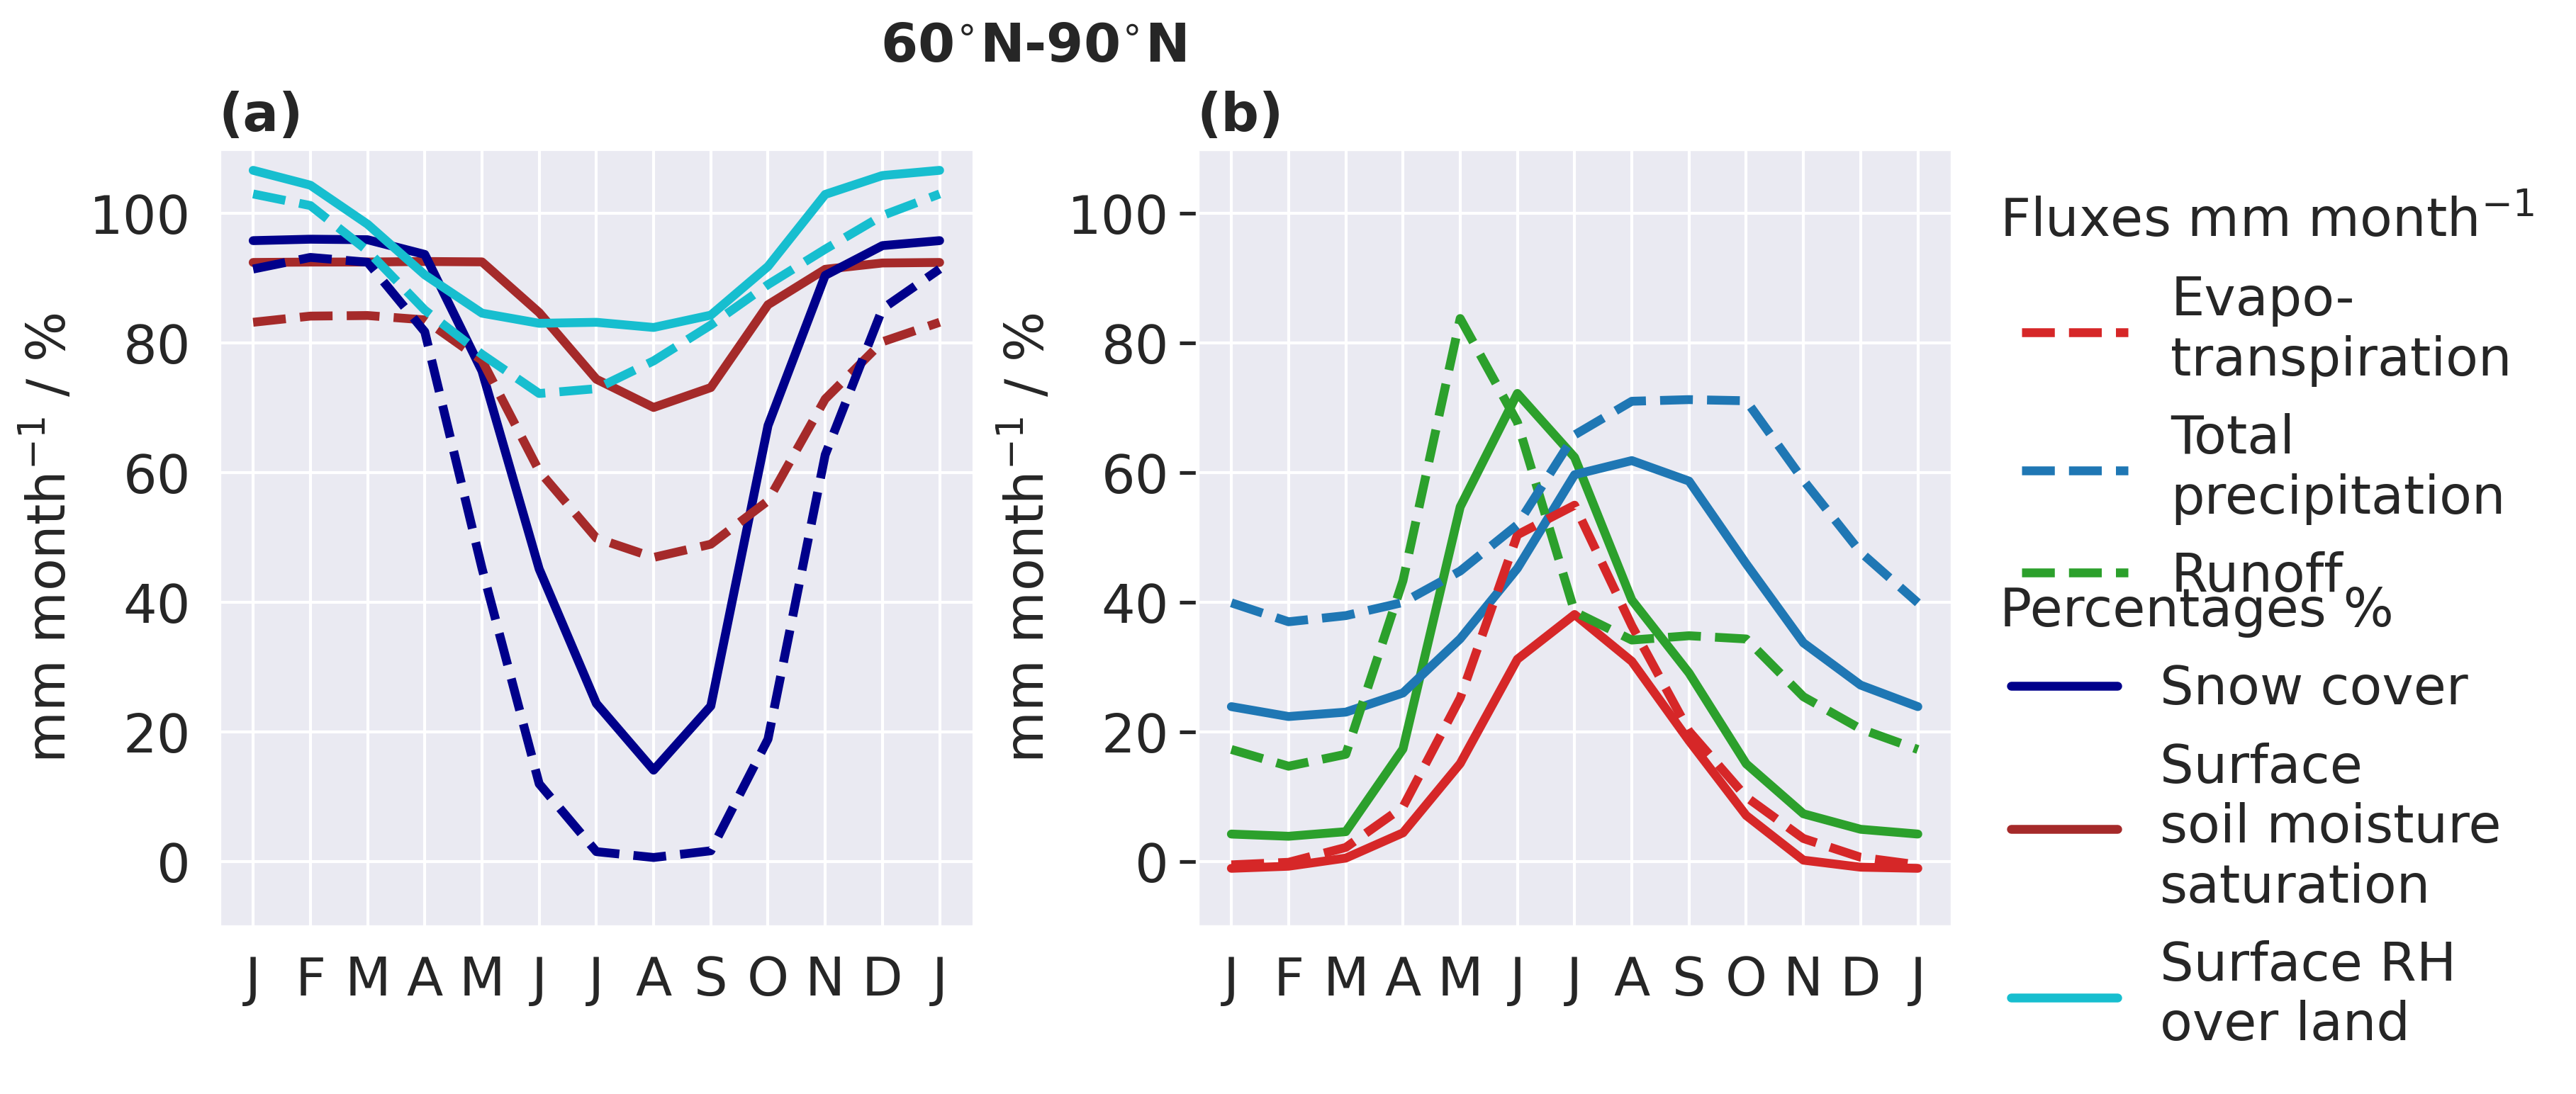

In [21]:
sns.set_theme()
months = np.arange(1, 14, 1)
monthnames = ['J', 'F', 'M', 'A', 'M', 'J', 'J', 'A', 'S', 'O', 'N', 'D', 'J']

labels = [['(a)','(b)']]
lw=3

fig, axs = plt.subplot_mosaic(mosaic=labels, figsize=(12, 5),dpi=300,constrained_layout=True)

# Left: percentages
label = '(a)'
ax = axs[label]
for ds, name, ls in zip([ds_piClim_i, ds_4xCO2_i], ['piClim', '4xCO2'],['-','--']):
# Soil saturation
    for var, c in zip(['FSOILSAT_10CM'], ['brown']):
        #avg = ((ds[var]*area_weights).sum(dim=['lon','lat']) - (ds_piClim_i[var]*area_weights).sum(dim=['lon','lat']))/(ds_piClim_i[var]*area_weights).sum(dim=['lon','lat'])*100
        #avg = (ds[var]*area_weights).sum(dim=['lon','lat'])/(ds_piClim_i[var].sel(month=5)*area_weights).sum(dim=['lon','lat'])*100 - (ds_piClim_i[var]*area_weights).sum(dim=['lon','lat'])/(ds_piClim_i[var].sel(month=5)*area_weights).sum(dim=['lon','lat'])*100     
        avg = (ds[var]*area_weights).sum(dim=['lon','lat'])*100
        avg_plus_J = list(avg.values)+[avg.isel(month=0).values]
        ax.plot(months, avg_plus_J, color=c, linestyle=ls, lw=lw)
    
    # Snow cover
    for var, c in zip(['FSNO'],  ['darkblue']):
        avg = (ds[var]*area_weights).sum(dim=['lon','lat'])*100
        avg_plus_J = list(avg.values)+[avg.isel(month=0).values]
        ax.plot(months, avg_plus_J, color=c, linestyle=ls, lw=lw)

    # Surface relative humidity
    if name == '4xCO2':
        #for var, c, ls in zip(['RELHUM', 'CLDLOW'], ['tab:orange','dimgray'], ['-','-']):
        for var, c, ls in zip(['RELHUM'], ['tab:cyan'], ['--']):
            if var=='CLDLOW':
                avg = (ds_4xCO2_RH_lnd[var])*100
            else:
                 avg = (ds_4xCO2_RH_lnd[var])
            avg_plus_J = list(avg.values)+[avg.isel(month=0).values]
            ax.plot(months, avg_plus_J, color=c, linestyle=ls, lw=lw)
    elif name == 'piClim':
        #for var, c, ls in zip(['RELHUM', 'CLDLOW'], ['tab:orange','dimgray'], ['-','-']):
         for var, c, ls in zip(['RELHUM'], ['tab:cyan'], ['-']):
            if var=='CLDLOW':
                avg = (piClim_RH_lnd[var])*100
            else:
                 avg = (piClim_RH_lnd[var])  
            avg_plus_J = list(avg.values)+[avg.isel(month=0).values]
            ax.plot(months, avg_plus_J, color=c, linestyle=ls, lw=lw)

#ax.set_title('', fontsize=18,fontweight='bold')
ax.set_ylim([-10,110])
ax.set_yticks([0, 20, 40, 60, 80, 100])
ax.set_yticklabels([0, 20, 40, 60, 80, 100], fontsize=18)
ax.set_ylabel('mm month$^{-1}$ / %', fontsize=18)
ax.set_xticks(months)
ax.set_xticklabels(monthnames, fontsize=18)

# Right: fluxes
label = '(b)'
ax = axs[label]
for ds, name, ls in zip([ds_piClim_i, ds_4xCO2_i], ['piClim', '4xCO2'],['-','--']):
    # For flux variables
    for var, c in zip(['QFLX_EVAP_TOT', 'QRUNOFF','PRECIP_TOTAL'], ['tab:red', 'tab:green','tab:blue']):
        avg = (ds[var]*area_weights).sum(dim=['lon','lat'])*60*60*24*30
        avg_plus_J = list(avg.values)+[avg.isel(month=0).values]
        ax.plot(months, avg_plus_J, color=c, linestyle=ls, lw=lw)


#ax.set_title(name, fontsize=18,fontweight='bold')
ax.set_ylim([-10,110])
ax.set_yticks([0, 20, 40, 60, 80, 100])
ax.set_yticklabels([0, 20, 40, 60, 80, 100], fontsize=18)
ax.set_ylabel('mm month$^{-1}$ / %', fontsize=18)
ax.set_xticks(months)
ax.set_xticklabels(monthnames, fontsize=18)



from matplotlib.lines import Line2D
from matplotlib.patches import Patch

legend_elements_1 = [Line2D([0], [0], color='tab:red', lw=lw, linestyle='--', label='Evapo-\ntranspiration'),
                   Line2D([0], [0], color='tab:blue', lw=lw, linestyle='--', label='Total\nprecipitation'),
                   Line2D([0], [0], color='tab:green', lw=lw, linestyle='--', label='Runoff')]

legend_elements_2 = [Line2D([0], [0], color='darkblue', lw=lw, linestyle='-', label='Snow cover'),
                Line2D([0], [0], color='brown', lw=lw, linestyle='-', label='Surface\nsoil moisture\nsaturation'),
                Line2D([0], [0], color='tab:cyan', lw=lw, linestyle='-', label='Surface RH\nover land')]


axs['(b)'].legend(handles=legend_elements_1, loc='upper left', bbox_to_anchor=(1, 1),frameon=False,
                title='Fluxes mm month$^{-1}$',fontsize=18,title_fontsize=18)
ax2 = axs['(b)'].twinx()
ax2.legend(handles=legend_elements_2, loc='upper left', bbox_to_anchor=(1, 0.5),frameon=False,
                title='Percentages %       ',fontsize=18,title_fontsize=18)
ax2.get_yaxis().set_visible(False)

# Label subplots
for label, ax in axs.items():
    ax.set_title(label, loc='left', fontsize=18,fontweight='bold')
fig.suptitle('60$^{\circ}$N-90$^{\circ}$N',x=0.4,fontsize=18,fontweight='bold')
#fig.savefig('/nird/datapeak/NS9600K/astridbg/arctic-cld-feedbacks/arctic-cloud-feedbacks/article_figs/Fig3.png')
#fig.savefig('/nird/datapeak/NS9600K/astridbg/arctic-cld-feedbacks/arctic-cloud-feedbacks/article_figs/Fig3.pdf')

plt.show()